# **Firsts Thoughts**

##### I'm trying to organize the project the following way:

* **Phase 1** — Learn what's in the CSV. Look at the shape of the data. Find the Ghost Ticks. Understand what's messy about it. No cleaning yet — just detective work.
* **Phase 2** — Build the transform step. Sort by ticker and time. Decide on imputation strategy (forward fill vs. interpolation) and produce a Golden Record.
* **Phase 3** — Pull data from Yahoo Finance and/or FRED. Align it with the cleaned CSV. Deal with the fact that these sources have different granularity and formats. (I have some questions about this).
* **Phase 4** — Add quality flags. Show statistical evidence that the Golden Record is trustworthy.
* **Phase 5** — Run some actual analysis on the clean data — correlations between sectors, volatility measures, maybe a simple risk model.


#### **Pre-analysis**

I first took the data to Excel and did some quick data investigation, which helped me understand the data a little better. Here are my conclusions:

- Data goes from 9:30 to 9:35 (5 minutes of data).
- Each ETF has 880 entries (doing quick math, on average that's around 2.933 entries per second).
- My guess is that the data is synthetic, since I find it hard to believe that those ETFs are that volatile (need to prove that).

-------------
##### **Coding**
-------------


In [2]:

# Libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [3]:

# Read CSV file from project
dataF = pd.read_csv("pedwar_raw_sector_ticks(in).csv")

####  **Step #1** - Data Transformation

So far, the only thing I have done is set the day and time into a unified structure, as well as setting all the times to the same date since that made more sense to me.

In [4]:

# Mask to separate formated dates of not fromated dates based "/"
dataTs = dataF['ts'].str.contains('/', na=False)

goodD = pd.to_datetime(dataF.loc[dataTs, 'ts']) 
badD = dataF.loc[~dataTs, 'ts'] # flag ~ tells just give me the bad ones 

In [5]:

# Separating the bad dates or wrong formated dates to make it as the good dates
partsTs = badD.str.split(':')
minutesTs = partsTs.str[0].astype(int) # Minutes
secondsTs = partsTs.str[1].astype(float) # Seconds 

transformDates = pd.to_datetime({
    'year': 2026, 
    'month': 2,
    'day': 12,
    'hour': 9,
    'minute': minutesTs,
    'second': secondsTs,
    # 'microsecond': ((secondstr % 1) * 1_000_000).astype(int)
})

In [6]:

dataF["timestamps"] = pd.NaT # Creating a new column 

# Populate the new column with all the formated values
dataF.loc[dataTs, "timestamps"] = goodD
dataF.loc[~dataTs, "timestamps"] = transformDates

# sample it, making sure is correct
sample = dataF[["ticker", "timestamps", "mid"]]
print(sample)

     ticker              timestamps       mid
0       XLV 2026-02-12 09:30:46.200   77.4112
1       XLI 2026-02-12 09:32:40.300  102.3113
2       XLU 2026-02-12 09:34:39.700  103.8194
3       XLV 2026-02-12 09:31:39.000   85.5453
4       XLC 2026-02-12 09:33:26.500   75.8172
...     ...                     ...       ...
9675    XLF 2026-02-12 09:30:34.300   87.2653
9676   XLRE 2026-02-12 09:30:15.400   94.3336
9677    XLB 2026-02-12 09:32:16.500  147.8646
9678    XLB 2026-02-12 09:30:12.900  109.6860
9679    XLB 2026-02-12 09:32:53.600  176.0393

[9680 rows x 3 columns]



#### **Step #2** - Check Point Analysis

I'm also trying to do some continuous analysis before I jump to the ghost ticks. From the following graph, you will see that an anomaly happens every minute across all ETFs.

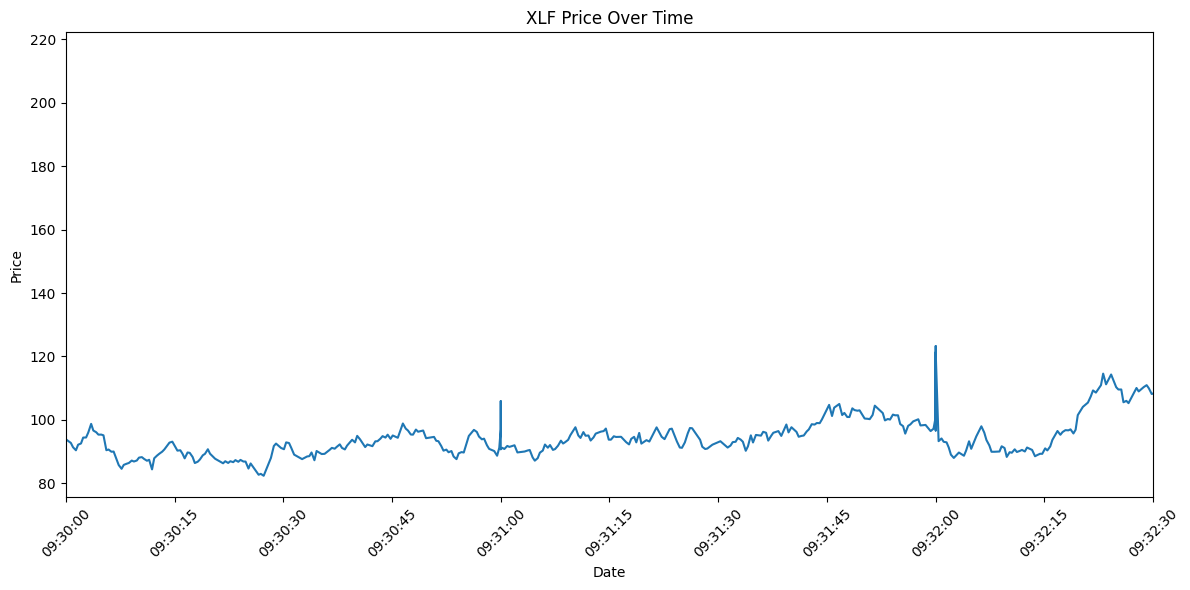

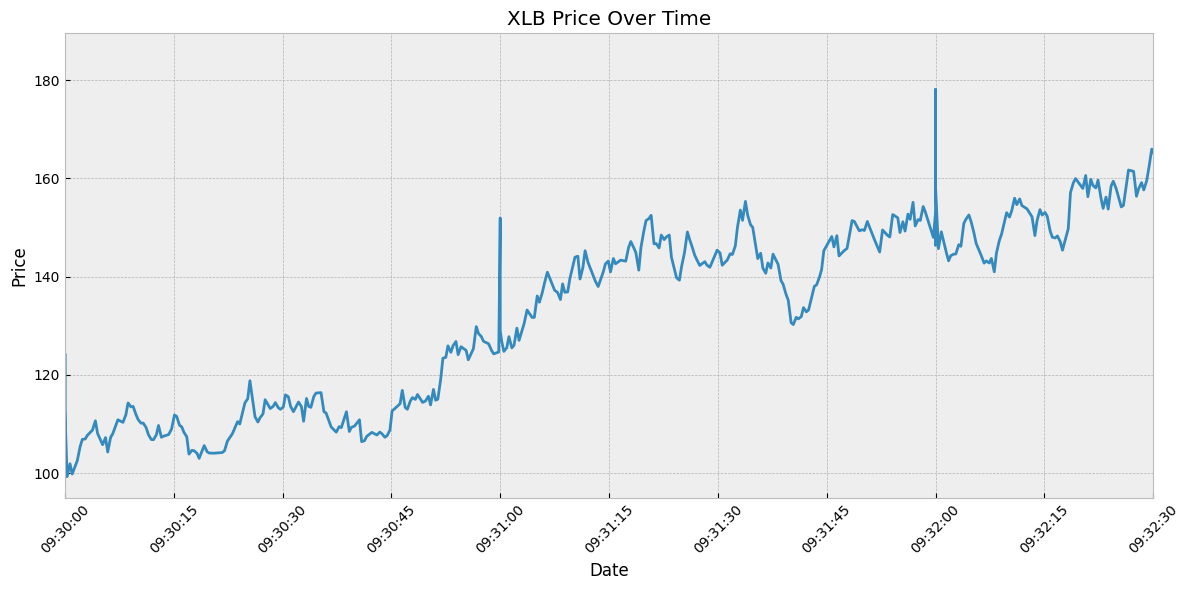

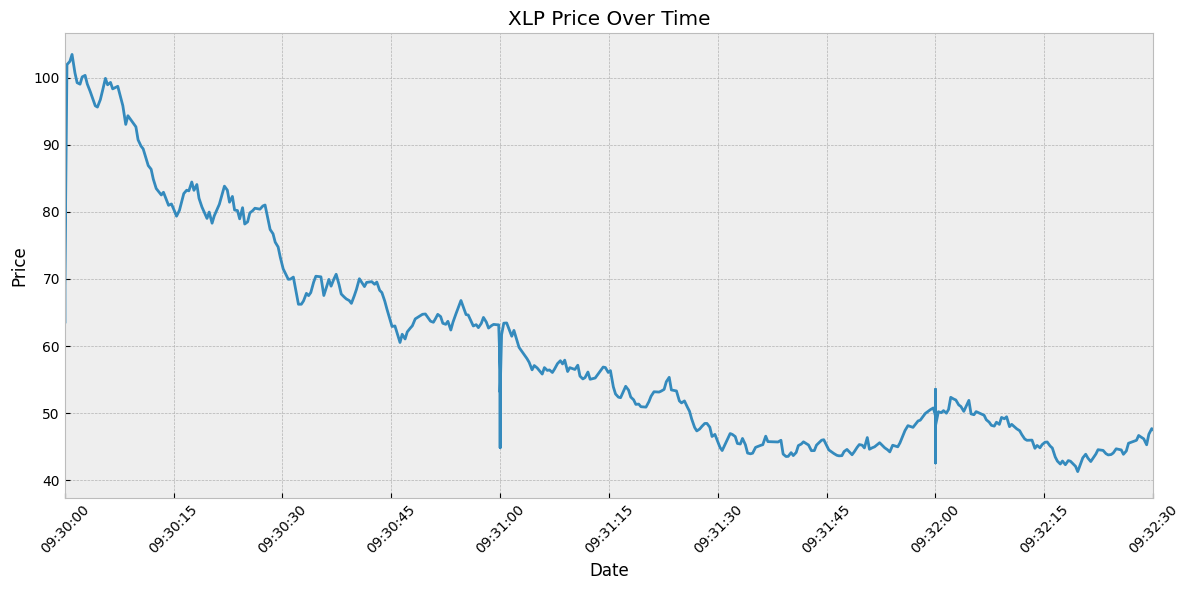

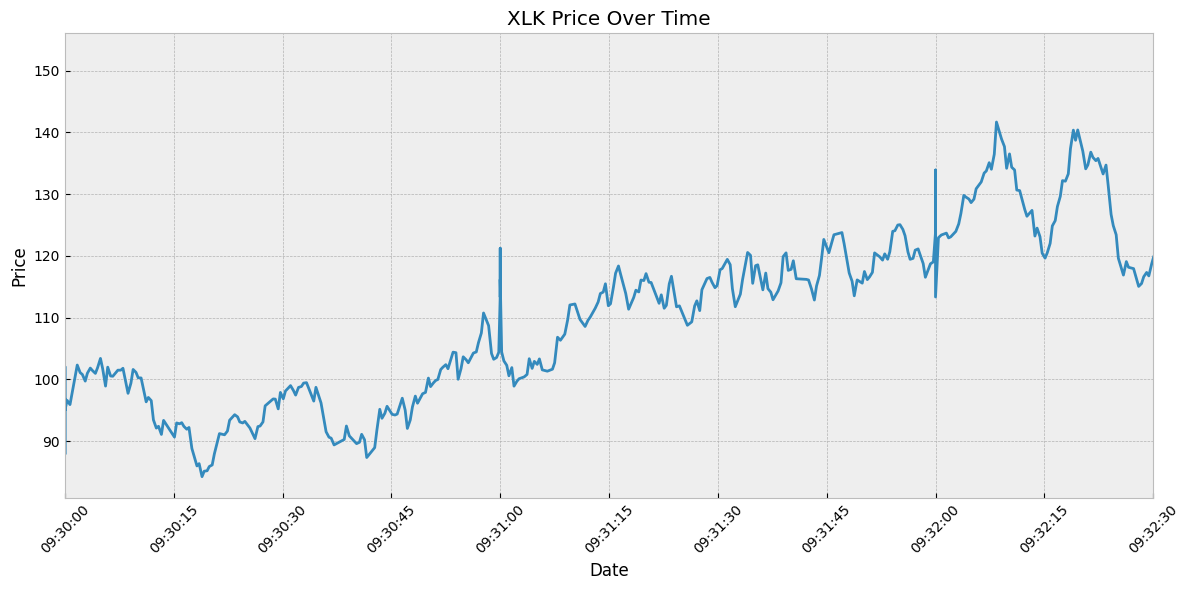

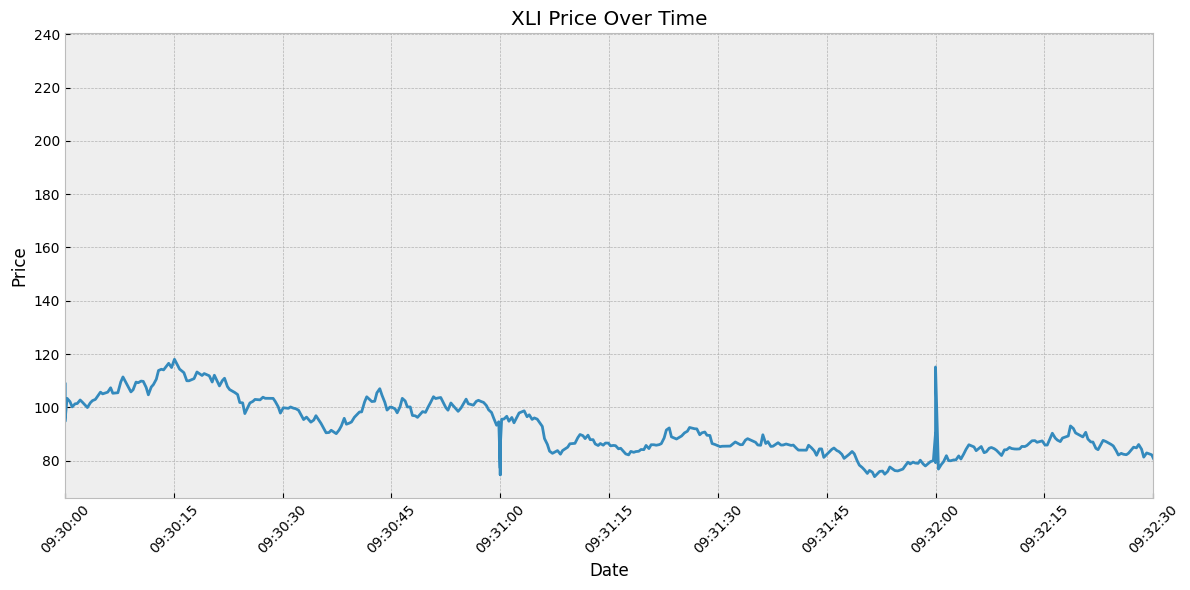

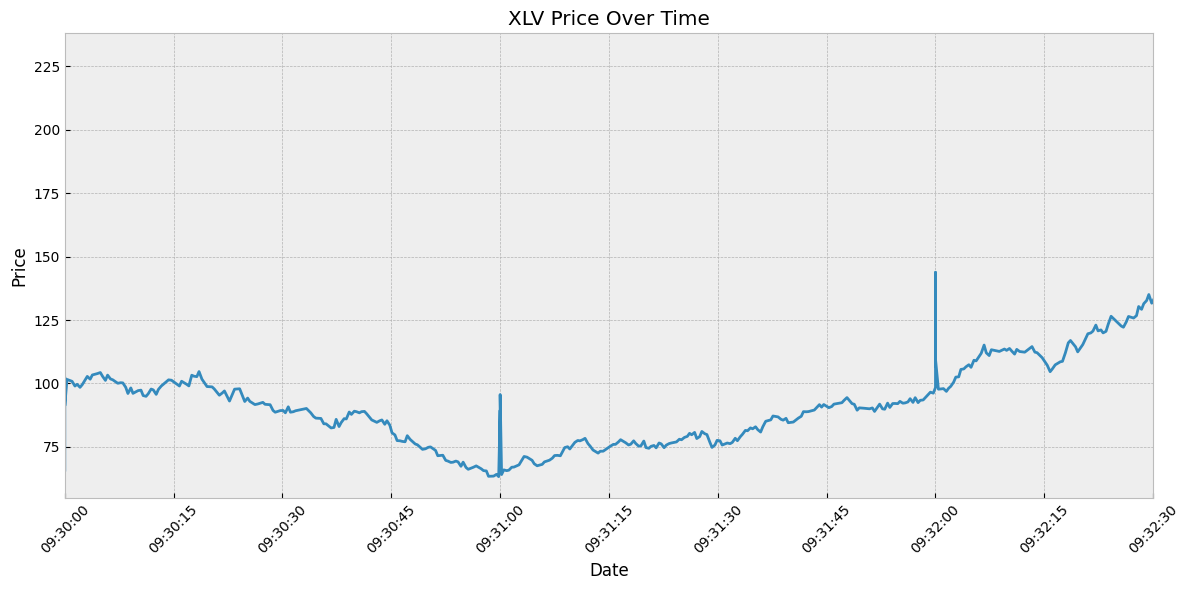

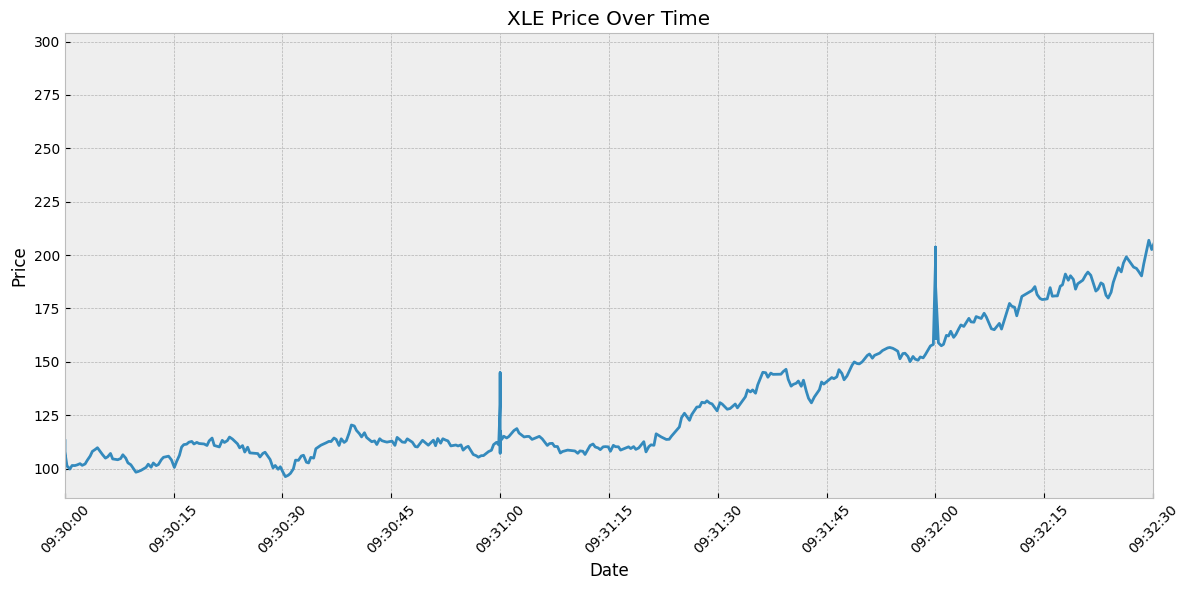

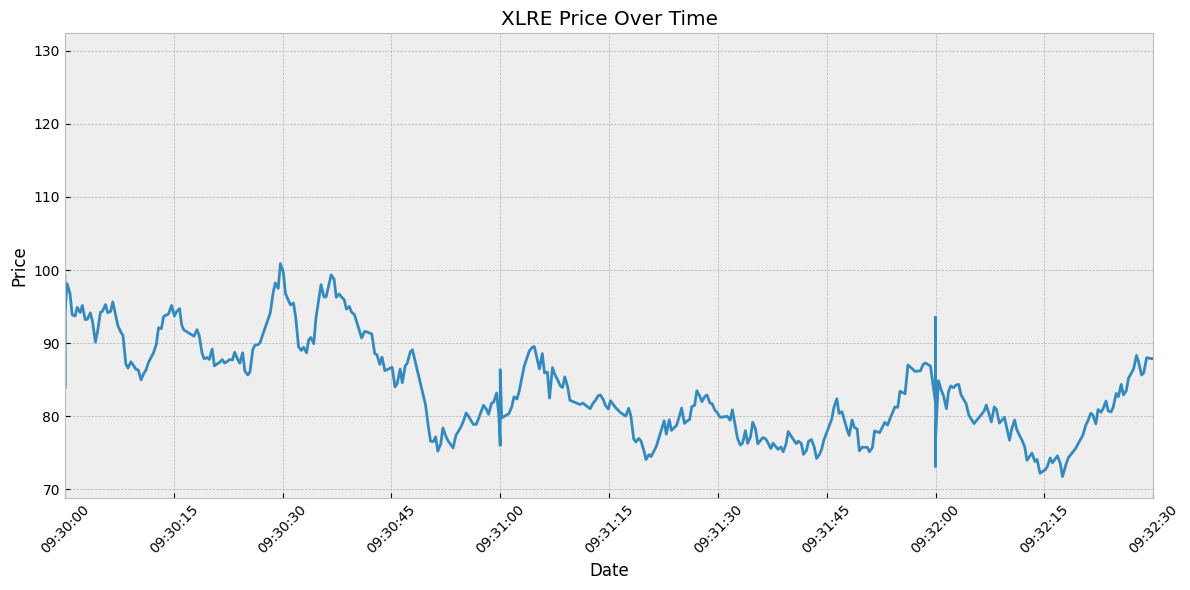

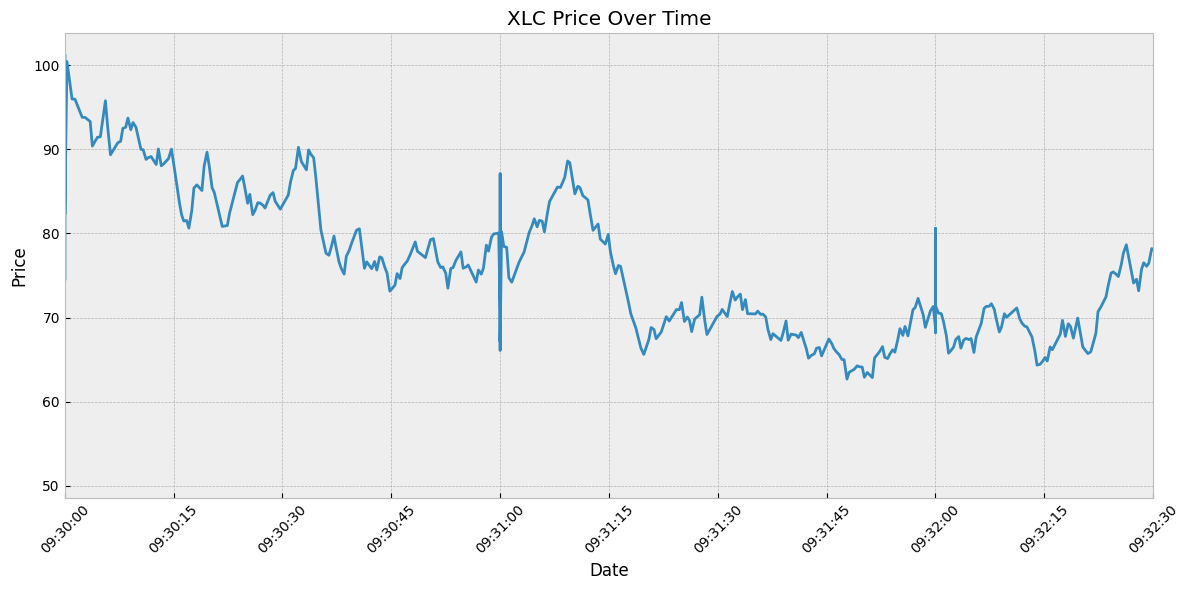

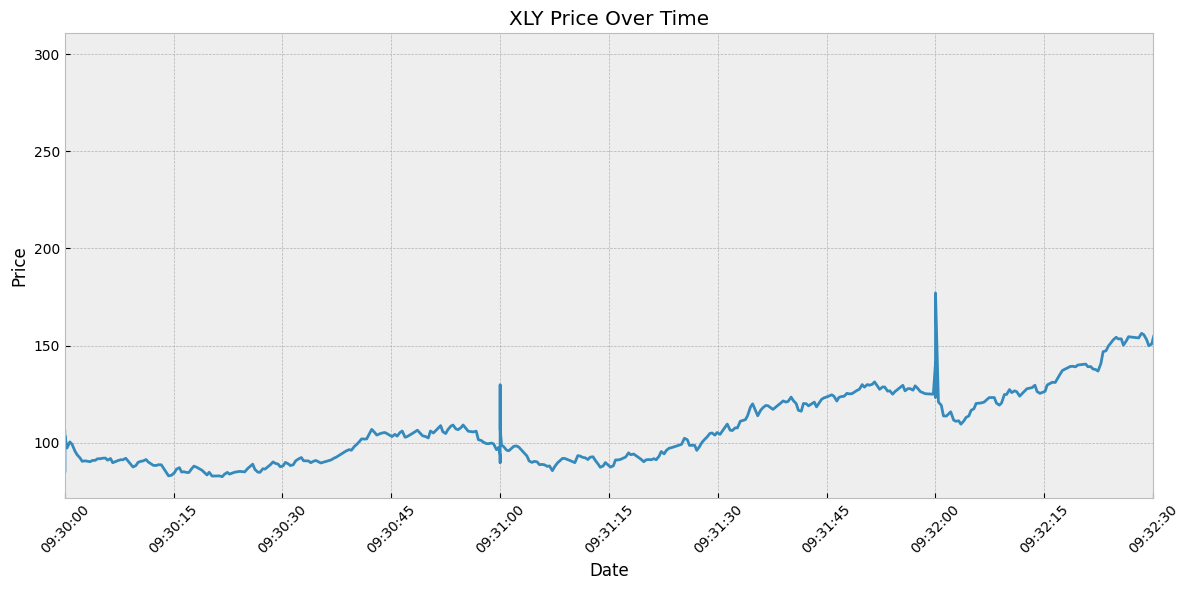

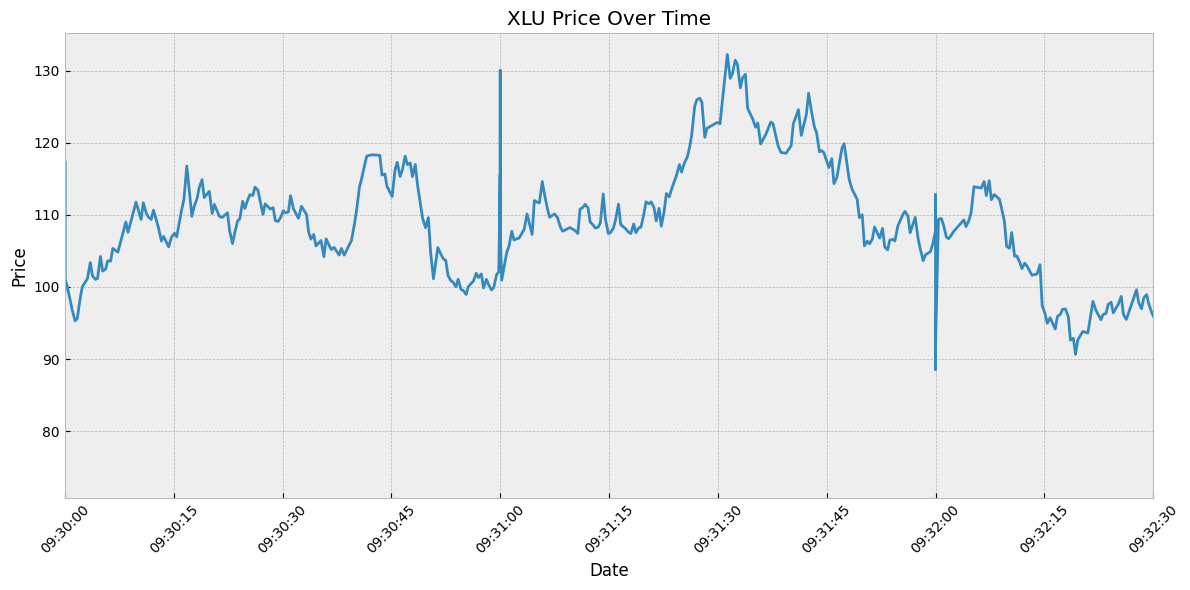

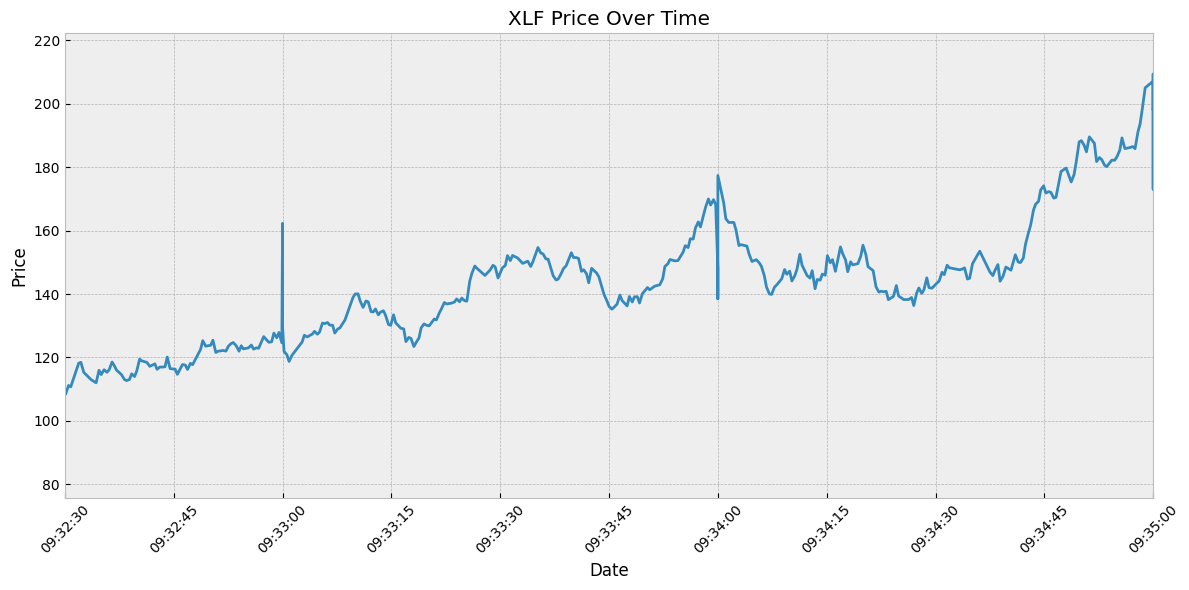

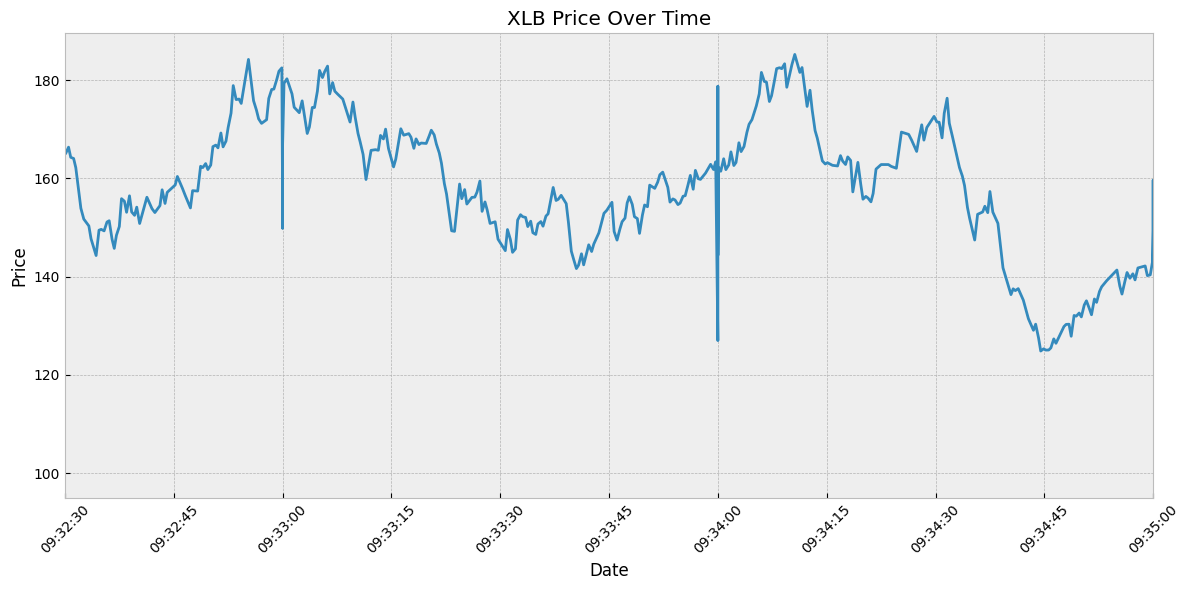

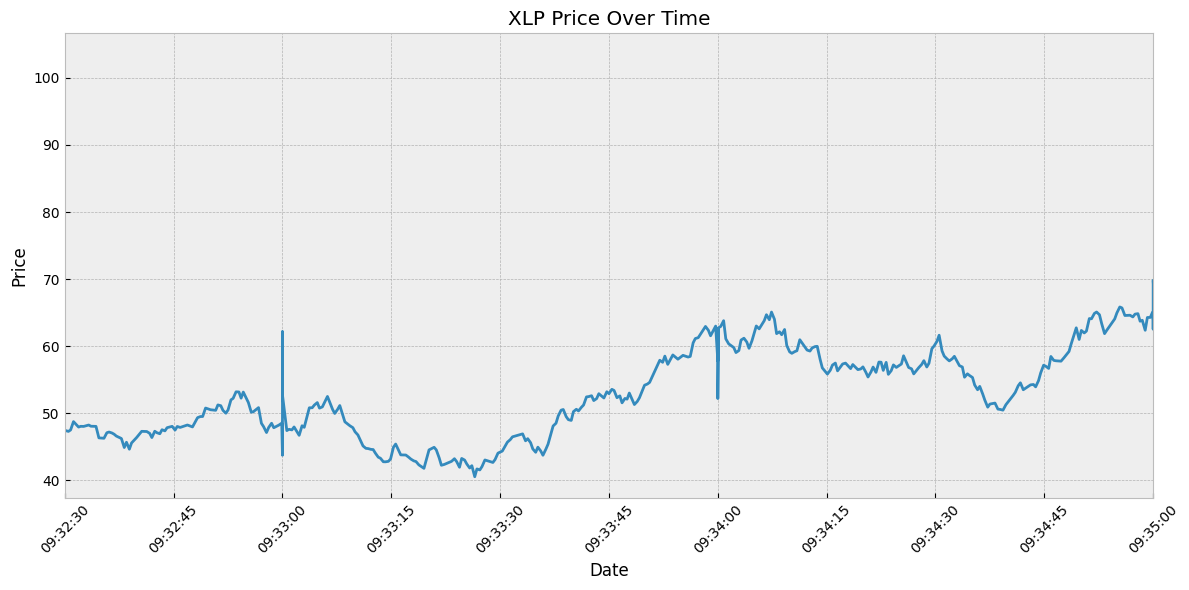

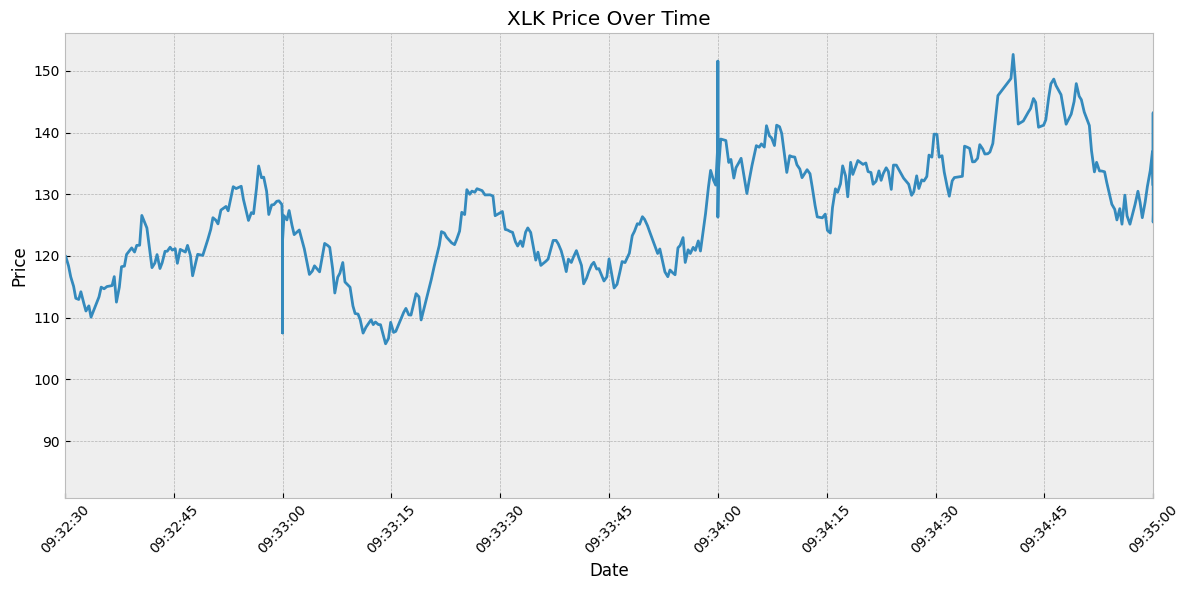

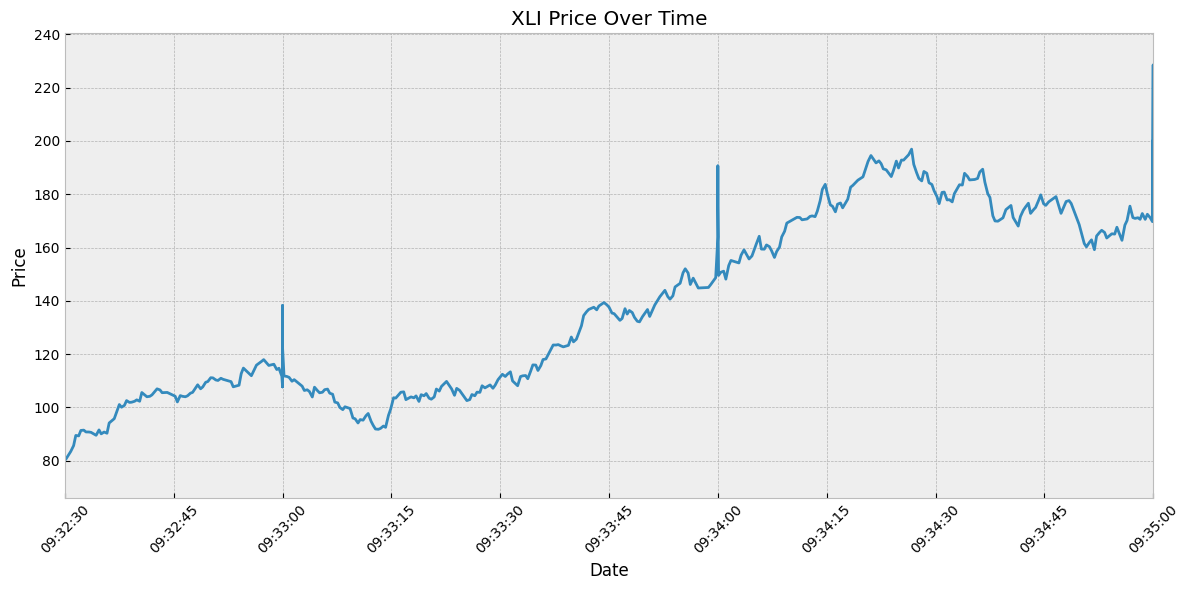

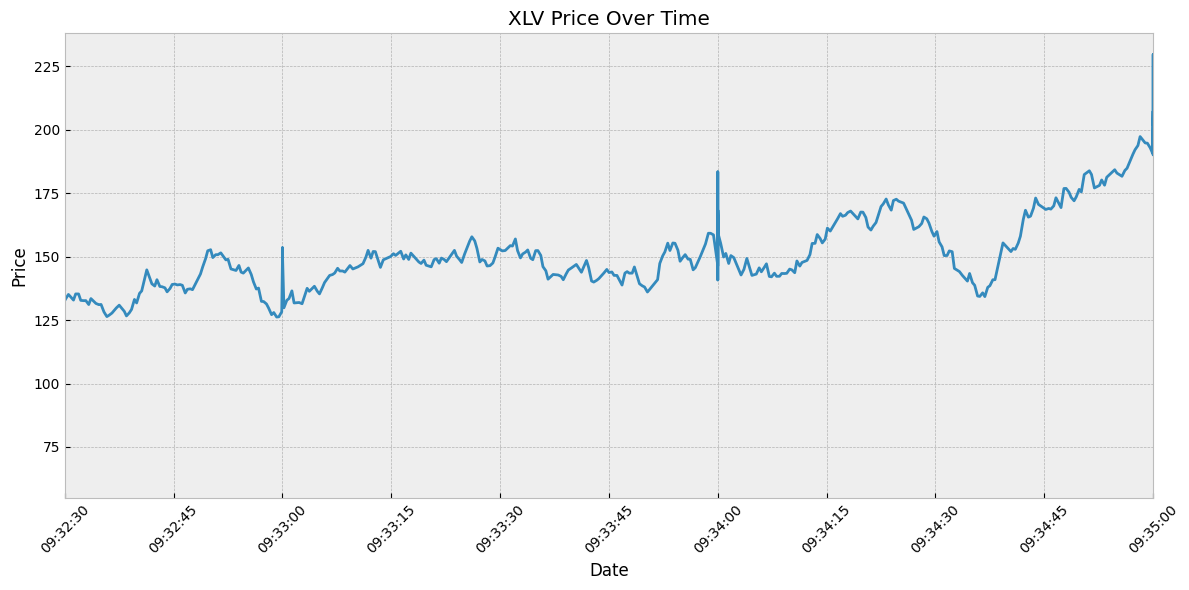

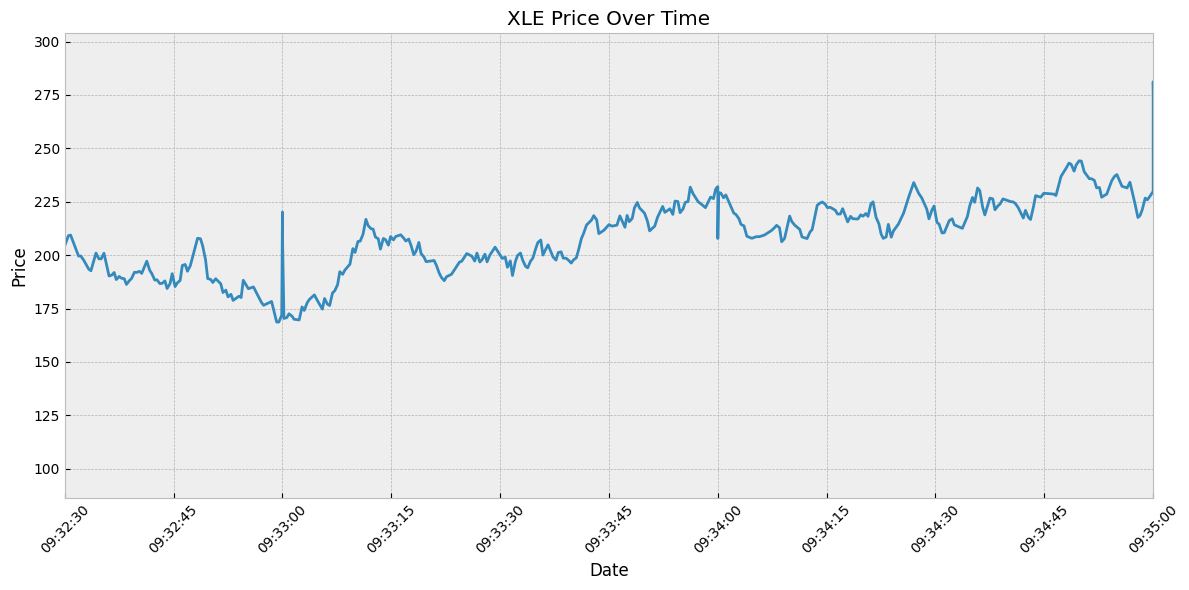

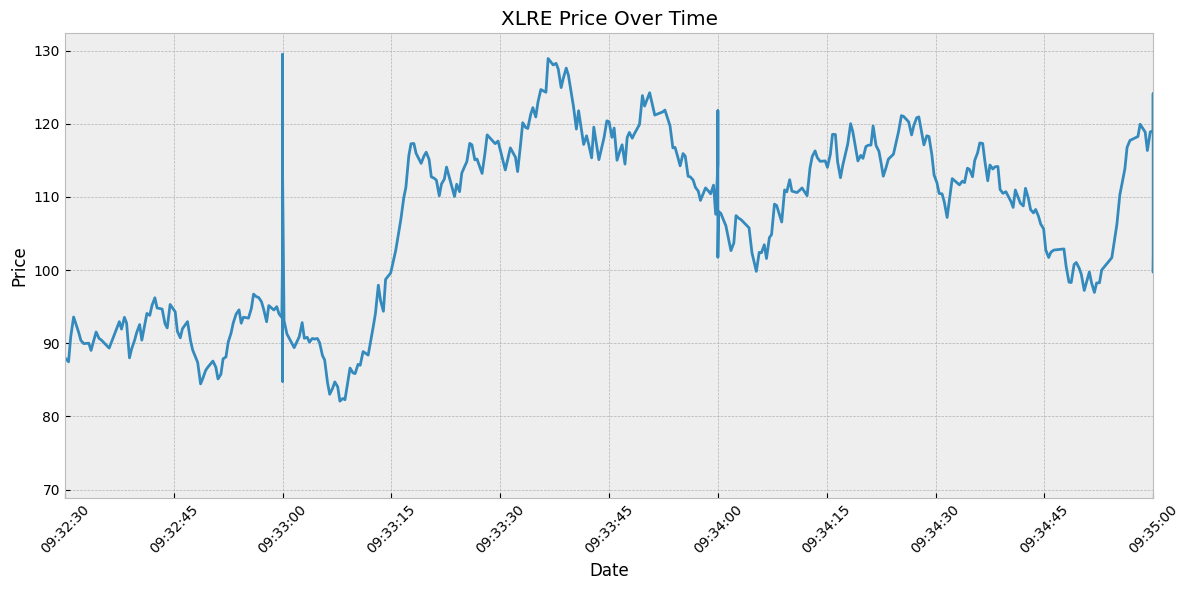

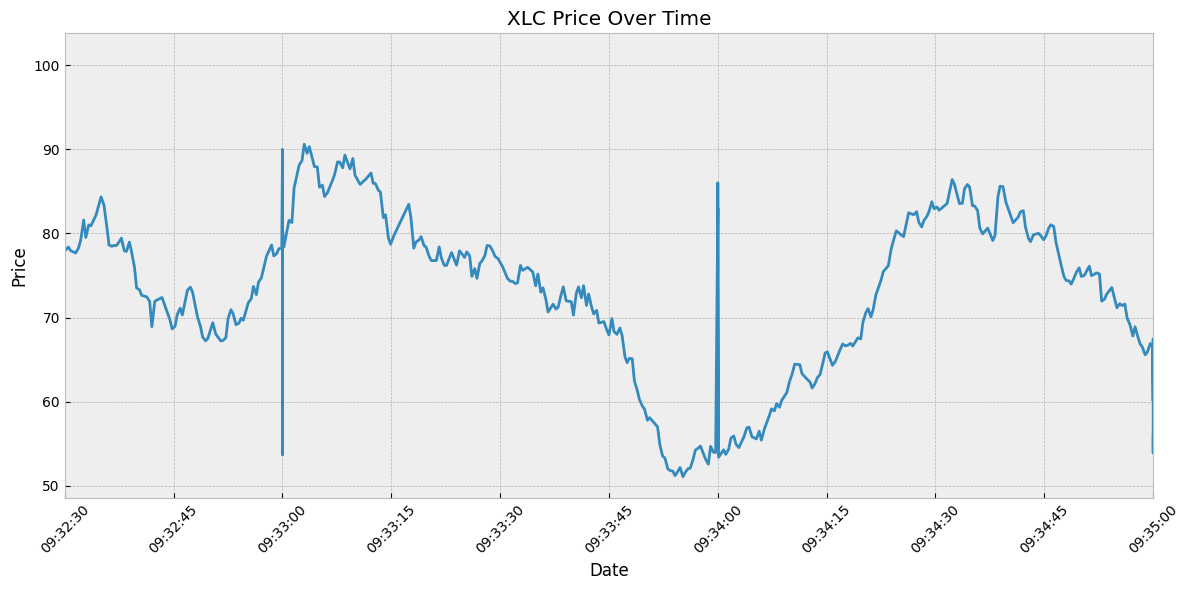

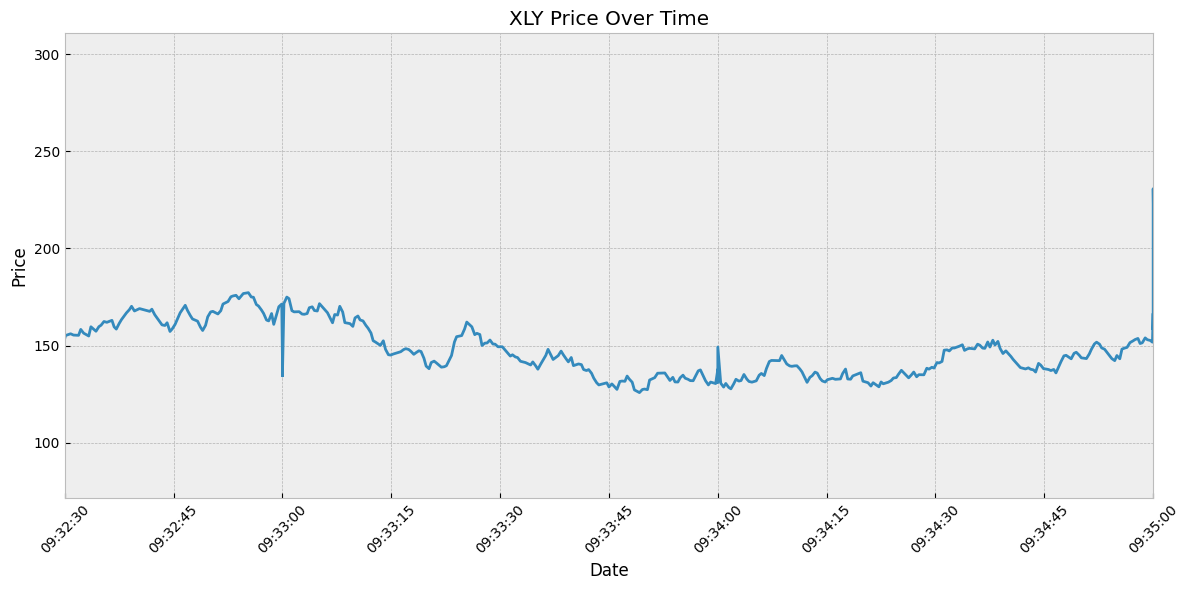

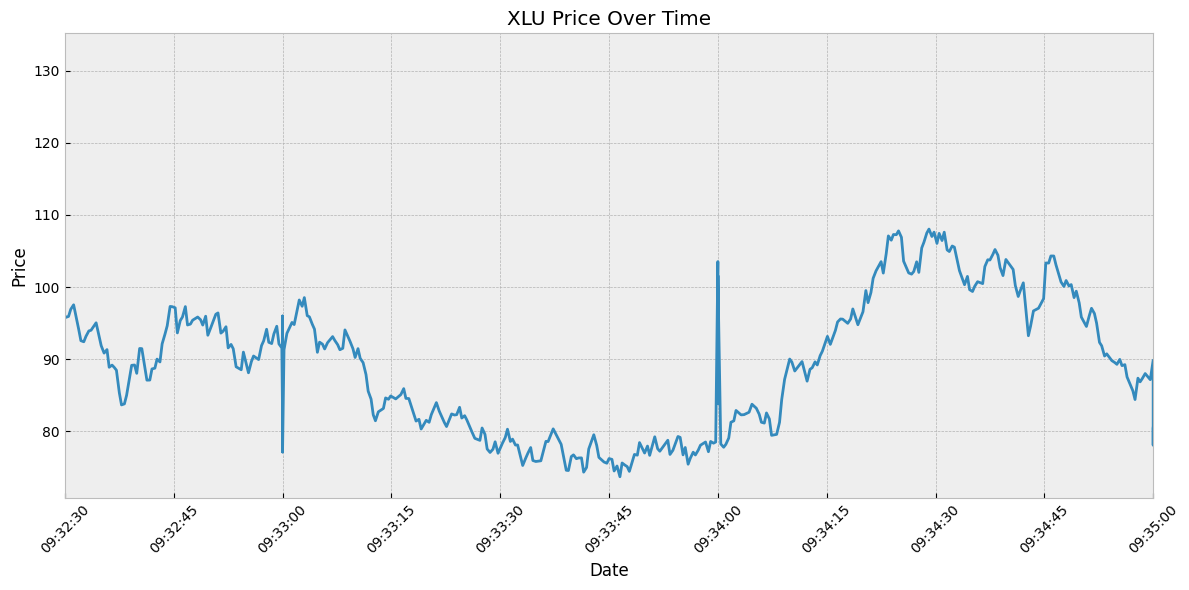

In [7]:

dataF = dataF.sort_values('timestamps') # Organize the data frame by time

# Graph stock movements to fins gaps in the data 
gstart = pd.Timestamp('2026-02-12 09:30:00')
gend = pd.Timestamp('2026-02-12 09:32:30')

gstart2 = pd.Timestamp('2026-02-12 09:32:30')
gend2 = pd.Timestamp('2026-02-12 09:35:00')

for stock in dataF["ticker"].unique():
    stock_data = dataF[dataF['ticker'] == stock]

    plt.figure(figsize=(12, 6))
    plt.plot(stock_data['timestamps'], stock_data['mid'], label = stock) # defining the X and Y axis 

    ax = plt.gca() # Get axis 
    ax.set_xlim(gstart, gend) # Defining limits 
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S')) # Format date to then: 
    ax.xaxis.set_major_locator(mdates.SecondLocator(interval = 15)) # Set Intervals of 15 seconds each 
    

    plt.xticks(rotation = 45)
    plt.title(f'{stock} Price Over Time') # each chart gets its stock name
    plt.style.use('bmh')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.tight_layout()
    plt.show()

# --- Second chart ---
for stock in dataF["ticker"].unique():
    stock_data = dataF[dataF['ticker'] == stock]

    plt.figure(figsize=(12, 6))
    plt.plot(stock_data['timestamps'], stock_data['mid'], label = stock)

    ax = plt.gca()
    ax.set_xlim(gstart2, gend2)
    ax.xaxis.set_major_locator(mdates.SecondLocator(interval = 15))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

    plt.xticks(rotation = 45)
    plt.title(f'{stock} Price Over Time') # each chart gets its stock name
    plt.style.use('bmh') # pre amde style by matplot lib 
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.tight_layout()
    plt.show()

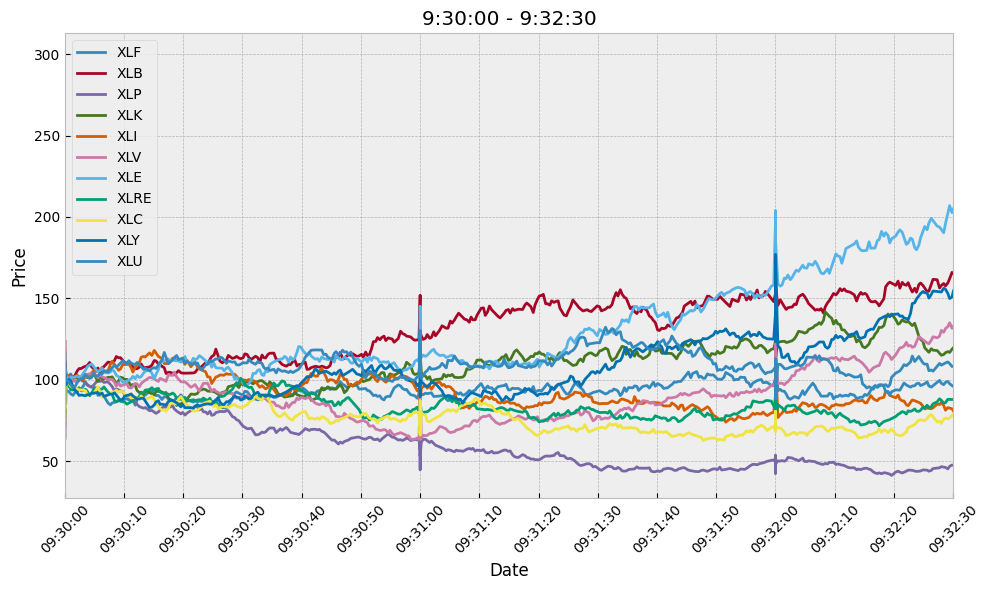

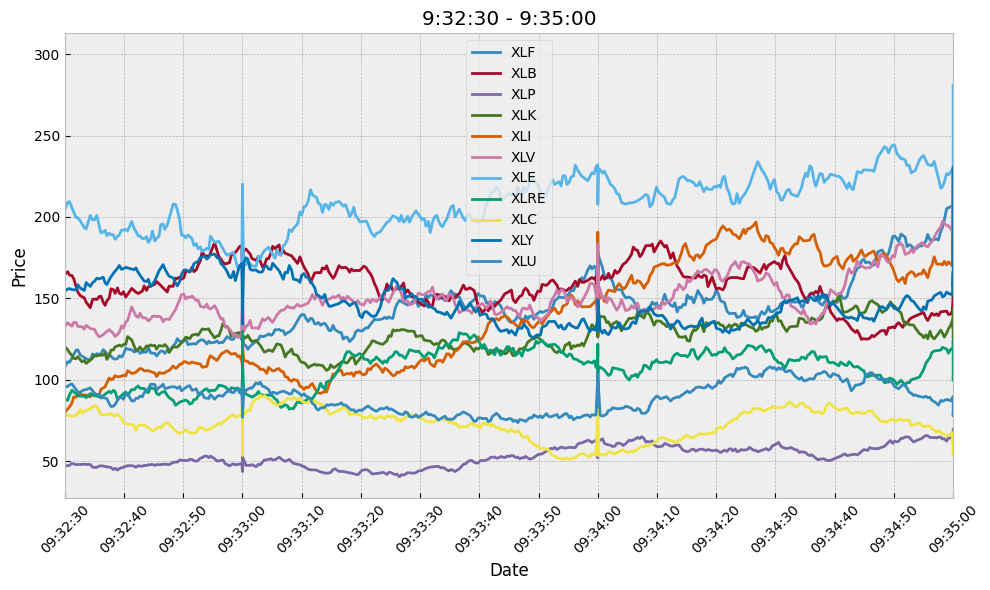

In [8]:

# General ETF's graphs 
plt.figure(figsize=(10, 6))

for stock in dataF["ticker"].unique():
    stock_data = dataF[dataF['ticker'] == stock]
    plt.plot(stock_data['timestamps'], stock_data['mid'], label=stock)

ax = plt.gca()
ax.set_xlim(gstart, gend)
ax.xaxis.set_major_locator(mdates.SecondLocator(interval=10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45)
plt.title('9:30:00 - 9:32:30')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

# --- Second chart ---
plt.figure(figsize=(10, 6))

for stock in dataF["ticker"].unique():
    stock_data = dataF[dataF['ticker'] == stock]
    plt.plot(stock_data['timestamps'], stock_data['mid'], label=stock)

ax = plt.gca()
ax.set_xlim(gstart2, gend2)
ax.xaxis.set_major_locator(mdates.SecondLocator(interval=10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45)
plt.title('9:32:30 - 9:35:00')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()


#### **Step #3** - Ghost Tickers Problem

In this seccion what I'm trying to solve is the fluctuation in the price of the stock every "60s". I wanted to demostrate and show different ways, methodolofies and applicable logic for this problem so you will see a lot of different analsysis and approaches for detecting the fluctuation.  


#### Test #1

In [9]:

# Analysis 

dataF["price_change"] = dataF.groupby('ticker')['mid'].diff().abs()
# print(dataF.groupby('ticker')['price_change'].describe())

# Getting the mean price by ETF taking into considerations all ticks
avg_all = dataF.groupby('ticker')['mid'].mean()
# print(avg_all)

# Getting the mean price by ETF taking into considerations all ticks but outliners by hard 
# coding the diffence

difference = 14.5
dataF['is_outlier'] = dataF["price_change"] > difference

avg = dataF.groupby(['ticker', 'is_outlier'])['mid'].mean()
# avg_time = dataF.groupby('timestamp')
print(avg)

# TRY BY STOCK 
stock_name = dataF['ticker'].iloc[0] # pick a stock
one_stock = dataF[dataF['ticker'] == stock_name]

# Show all the rows flagged as outliers
print(one_stock[one_stock['is_outlier']][['timestamps', 'mid', 'price_change']])

# This approach comes with idfferent problems: 
   # 1. Not all stocks have the same difference between normal price and fluctuations.
   # 2. When the price goes back to normal some stocks will come back in smaller amounts 
#       that are undetectable with the hard coded diff. """




ticker  is_outlier
XLB     False         145.755198
        True          152.442187
XLC     False          72.298441
        True           76.269162
XLE     False         180.219962
        True          198.262991
XLF     False         128.483074
        True          155.274755
XLI     False         125.630287
        True          152.963253
XLK     False         120.398448
        True          133.331750
XLP     False          57.858771
        True           75.204729
XLRE    False          96.650686
        True          104.072978
XLU     False          97.123121
        True          101.773086
XLV     False         131.630365
        True          132.619892
XLY     False         138.343712
        True          150.706219
Name: mid, dtype: float64
                  timestamps       mid  price_change
7149 2026-02-12 09:32:00.000  107.4551       15.8065
2300 2026-02-12 09:32:00.000  121.3526       24.7066
1775 2026-02-12 09:32:00.400   93.2846       28.0680
4241 2026-02-12 0

Based on that different previusly hard coded then we can calulated the average before the outlier.

In [10]:
results = []

outliers = one_stock[one_stock['is_outlier']]

for idx in outliers.index:
    # Get all rows BEFORE this outlier
    before = one_stock[one_stock.index < idx]
    
    # Keep only the normal ones
    normal_before = before[~before['is_outlier']]
    
    # Calculate the average
    if len(normal_before) > 0:
        avg_before = normal_before['mid'].mean()
        count = len(normal_before)
    else:
        avg_before = None
        count = 0
    
    results.append({
        'ticker': stock_name,
        'outlier_time': one_stock.loc[idx, 'timestamps'],
        'outlier_price': one_stock.loc[idx, 'mid'],
        'avg_before': avg_before,
        'normal_ticks_counted': count
    })

results_table = pd.DataFrame(results)
print(results_table)


   ticker            outlier_time  outlier_price  avg_before  \
0     XLF 2026-02-12 09:32:00.000       107.4551  128.412967   
1     XLF 2026-02-12 09:32:00.000       121.3526  129.299262   
2     XLF 2026-02-12 09:32:00.400        93.2846  127.785733   
3     XLF 2026-02-12 09:33:00.000       162.3160  129.089656   
4     XLF 2026-02-12 09:33:00.000       142.5002  125.609277   
5     XLF 2026-02-12 09:34:00.000       147.9347  129.582057   
6     XLF 2026-02-12 09:34:00.000       177.3892  128.576205   
7     XLF 2026-02-12 09:35:00.000       175.2990  143.816520   
8     XLF 2026-02-12 09:35:00.000       209.4003  128.850054   
9     XLF 2026-02-12 09:35:00.000       173.0581  147.082991   
10    XLF 2026-02-12 09:35:00.000       198.0325  128.849665   

    normal_ticks_counted  
0                    650  
1                    223  
2                    171  
3                    409  
4                     92  
5                    479  
6                    350  
7              

#### Test #2 

Here are three ddifferent approaches at one that I tried to do to then see which one of them had the best results. 

1. **Usign the standar deviation:** Most price changes cluster around an average. If a change is WAY bigger than average, it's suspicious.
2. **IQR:** Instead of using mean and std (which get pulled by extreme values), use percentiles which ignore extremes.
3. **Percentage Change:** Instead of looking at the dollar amount, look at the percentage. A $5 move on a $100 stock (5%) is very different from a $5 move on a $500 stock (1%).

None of them worked perfectly because the ghost ticks in the middle of clusters have small changes the price change from one tick to the next. This fails because ghost ticks come in clusters of 7-8, and the ticks within a cluster have small changes between each other (e.g., 151 to 146 is only 5) even though they're all far from the real price. So the middle ticks in every cluster look "normal" to any threshold-based approach, no matter how you calculate the threshold - the methods can only catch the first and last tick of each cluster where the big jump happens. But running all three and comparing against the known answer is how I decided to evaluate detection methods since I needed a true statement to compere the results with. 



In [11]:
# Compare all three methods
def flag_std(group):
    change = group['mid'].diff().abs()
    return change > (change.mean() + 2 * change.std())

def flag_iqr(group):
    change = group['mid'].diff().abs()
    q1, q3 = change.quantile(0.25), change.quantile(0.75)
    return change > (q3 + 1.5 * (q3 - q1))

def flag_pct(group):
    return group['mid'].pct_change().abs() > 0.05

dataF['outlier_std'] = dataF.groupby('ticker', group_keys=False).apply(flag_std)
dataF['outlier_iqr'] = dataF.groupby('ticker', group_keys=False).apply(flag_iqr)
dataF['outlier_pct'] = dataF.groupby('ticker', group_keys=False).apply(flag_pct)

# Also flag by the known pattern (our ground truth)
dataF['outlier_exact'] = (
    (dataF['timestamps'].dt.second == 0) & 
    (dataF['timestamps'].dt.microsecond == 0)
)

# Compare: how many did each method catch?
print("=== Outliers detected per method ===")
print(f"{'Method':<20} {'Total flagged':<15} {'Correct (ghost)':<18} {'False positives'}")
print("-" * 70)

for method in ['outlier_std', 'outlier_iqr', 'outlier_pct']:
    total = dataF[method].sum()
    correct = (dataF[method] & dataF['outlier_exact']).sum()
    false_pos = total - correct
    print(f"{method:<20} {total:<15} {correct:<18} {false_pos}")

actual = dataF['outlier_exact'].sum()
print(f"\n{'Actual ghost ticks:':<20} {actual}")

# Per-stock breakdown
print("\n=== Per-stock comparison ===")
for stock in sorted(dataF['ticker'].unique()):
    s = dataF[dataF['ticker'] == stock]
    exact = s['outlier_exact'].sum()
    std_c = (s['outlier_std'] & s['outlier_exact']).sum()
    iqr_c = (s['outlier_iqr'] & s['outlier_exact']).sum()
    pct_c = (s['outlier_pct'] & s['outlier_exact']).sum()
    print(f"{stock}: {exact} ghost ticks | caught by std: {std_c}, iqr: {iqr_c}, pct: {pct_c}")

=== Outliers detected per method ===
Method               Total flagged   Correct (ghost)    False positives
----------------------------------------------------------------------
outlier_std          278             229                49
outlier_iqr          564             322                242
outlier_pct          417             314                103

Actual ghost ticks:  482

=== Per-stock comparison ===
XLB: 45 ghost ticks | caught by std: 20, iqr: 25, pct: 23
XLC: 46 ghost ticks | caught by std: 27, iqr: 37, pct: 37
XLE: 45 ghost ticks | caught by std: 20, iqr: 27, pct: 28
XLF: 40 ghost ticks | caught by std: 17, iqr: 23, pct: 22
XLI: 41 ghost ticks | caught by std: 17, iqr: 26, pct: 24
XLK: 44 ghost ticks | caught by std: 21, iqr: 23, pct: 21
XLP: 43 ghost ticks | caught by std: 16, iqr: 31, pct: 31
XLRE: 47 ghost ticks | caught by std: 21, iqr: 31, pct: 32
XLU: 42 ghost ticks | caught by std: 23, iqr: 30, pct: 28
XLV: 45 ghost ticks | caught by std: 29, iqr: 36, pct: 34
XLY:

#### Test #3 - **Winner Approach**

The count-based method works because ghost ticks have a unique structural fingerprint: multiple ticks sharing the exact same timestamp for the same stock, which never happens in normal data. Instead of looking at price (which overlaps between normal and ghost), it looks at density, normal ticks always appear alone at their timestamp (count = 1), while ghost ticks always appear in clusters of 5-9 at the same timestamp, with a clean gap in between (no counts of 2, 3, or 4). This makes it 100% accurate with zero false positives, and it would work even if ghost ticks happened at random times or had prices identical to normal ticks.

In [13]:
dataF = dataF.sort_values(['ticker', 'timestamps']).reset_index(drop=True)

# Method 1: Count-based (what we just did)
tick_counts = dataF.groupby(['ticker', 'timestamps']).transform('size')
dataF['is_ghost'] = tick_counts > 1

# Method 2: Timestamp-based (second == 0)
dataF['ghost_by_time'] = (
    (dataF['timestamps'].dt.second == 0) & 
    (dataF['timestamps'].dt.microsecond == 0)
)

# Do they match?
both = (dataF['is_ghost'] == dataF['ghost_by_time']).all()
print(f"Both methods agree on every row: {both}")

# If not, show the differences
if not both:
    diff = dataF[dataF['ghost_by_count'] != dataF['ghost_by_time']]
    print(f"Rows where they disagree: {len(diff)}")
    print(diff[['ticker', 'timestamps', 'mid', 'ghost_by_count', 'ghost_by_time']])

# Verify
print(f"Ghost ticks found: {dataF['is_ghost'].sum()}")
print(f"Normal ticks: {(~dataF['is_ghost']).sum()}")

# See the counts distribution
print("\nTicks per timestamp:")
print(tick_counts.value_counts().sort_index())

# --

reduced = dataF.drop_duplicates(subset=['ticker', 'timestamps'], keep='first').copy()
reduced = reduced.sort_values(['ticker', 'timestamps']).reset_index(drop=True)

print(f"Original: {len(dataF)} rows")
print(f"After removing duplicates: {len(reduced)} rows")
print(f"Ghost ticks remaining (1 per cluster): {reduced['is_ghost'].sum()}")

reduced.loc[reduced['is_ghost'], 'mid'] = float('nan')
reduced['mid'] = reduced.groupby('ticker')['mid'].transform(
    lambda x: x.interpolate(method='linear')
)

print(f"After interpolation: {reduced['mid'].isna().sum()} missing values remaining")


Both methods agree on every row: True
Ghost ticks found: 482
Normal ticks: 9198

Ticks per timestamp:
1    9198
5      20
6      66
7     154
8     152
9      90
Name: count, dtype: int64
Original: 9680 rows
After removing duplicates: 9264 rows
Ghost ticks remaining (1 per cluster): 66
After interpolation: 11 missing values remaining


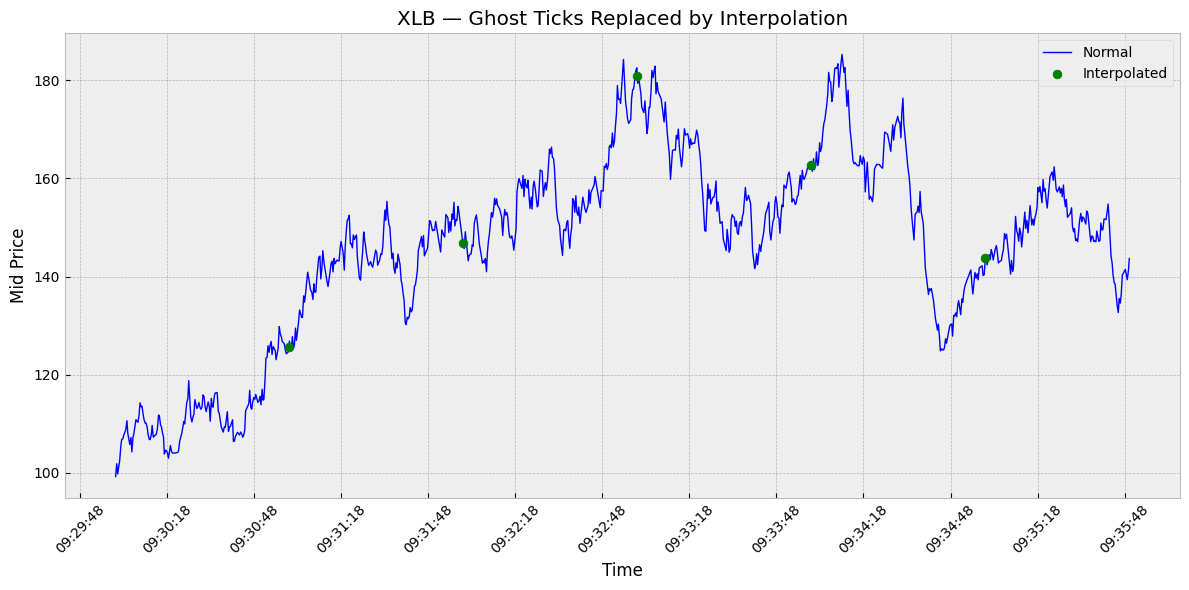

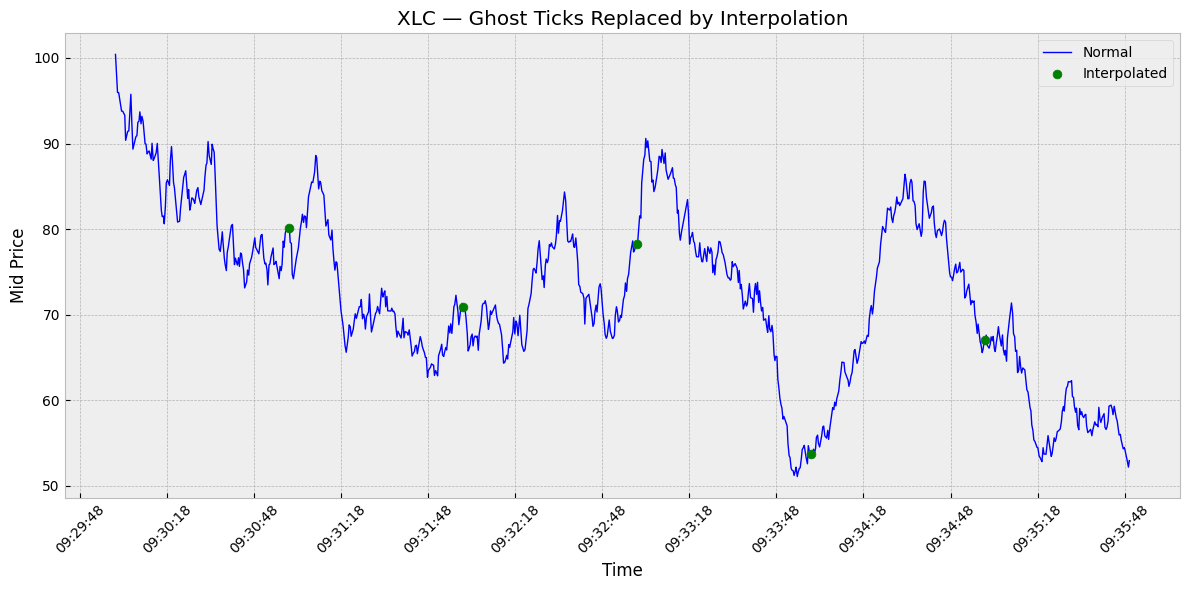

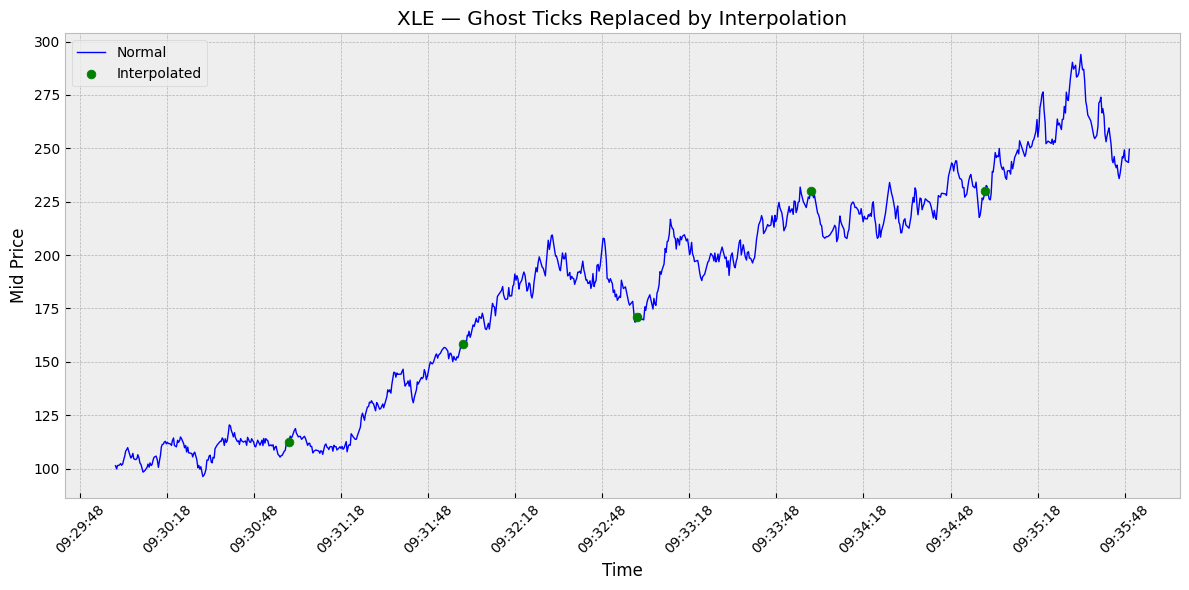

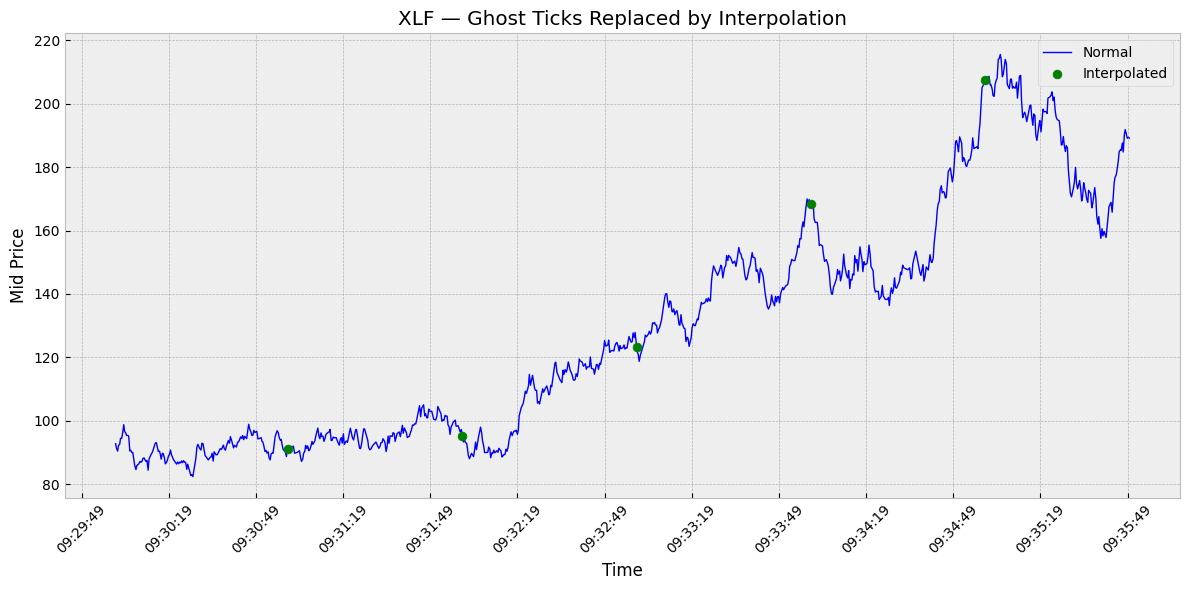

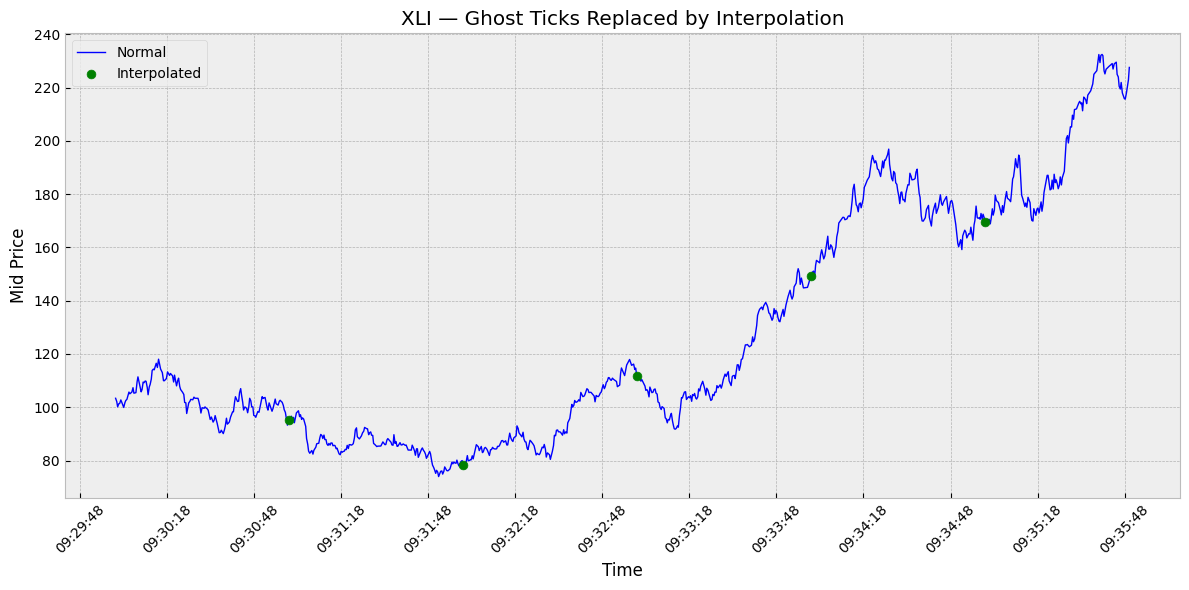

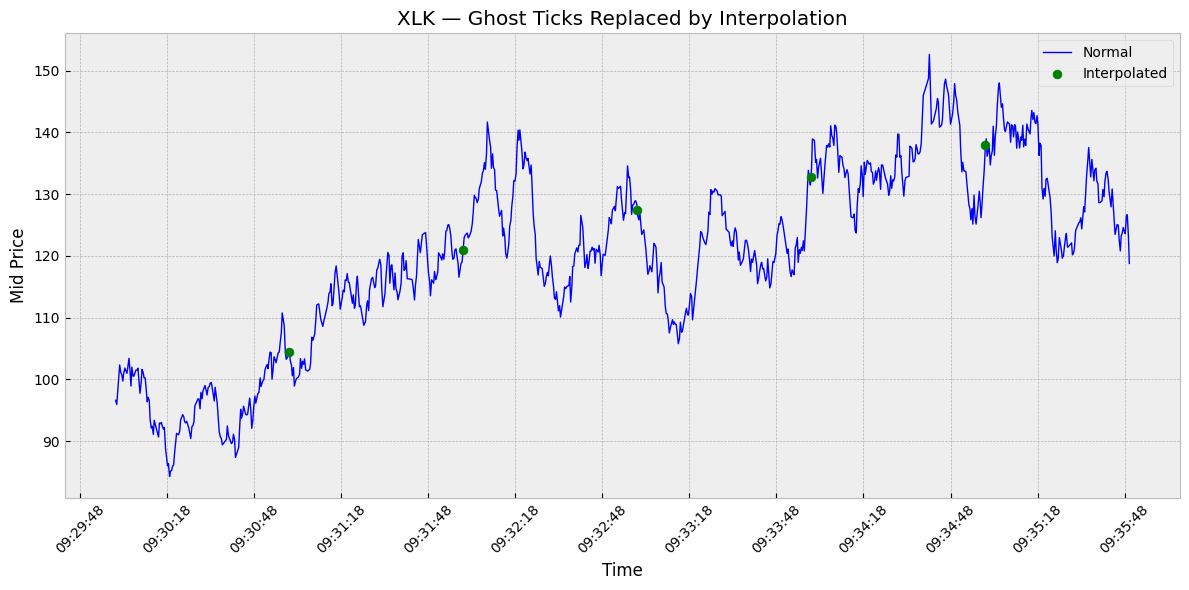

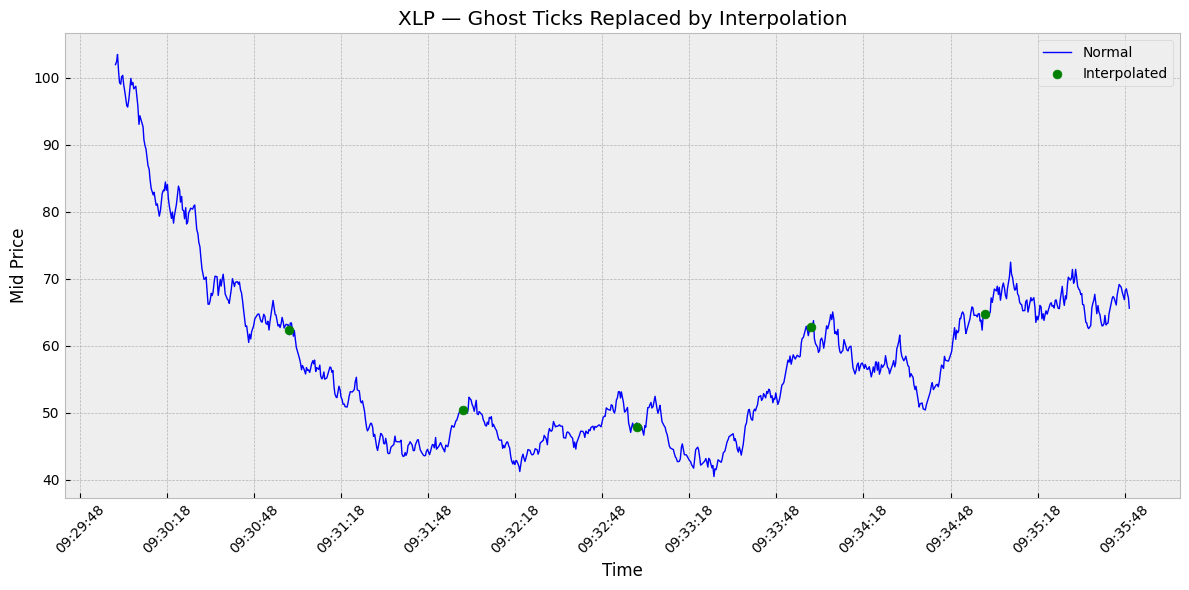

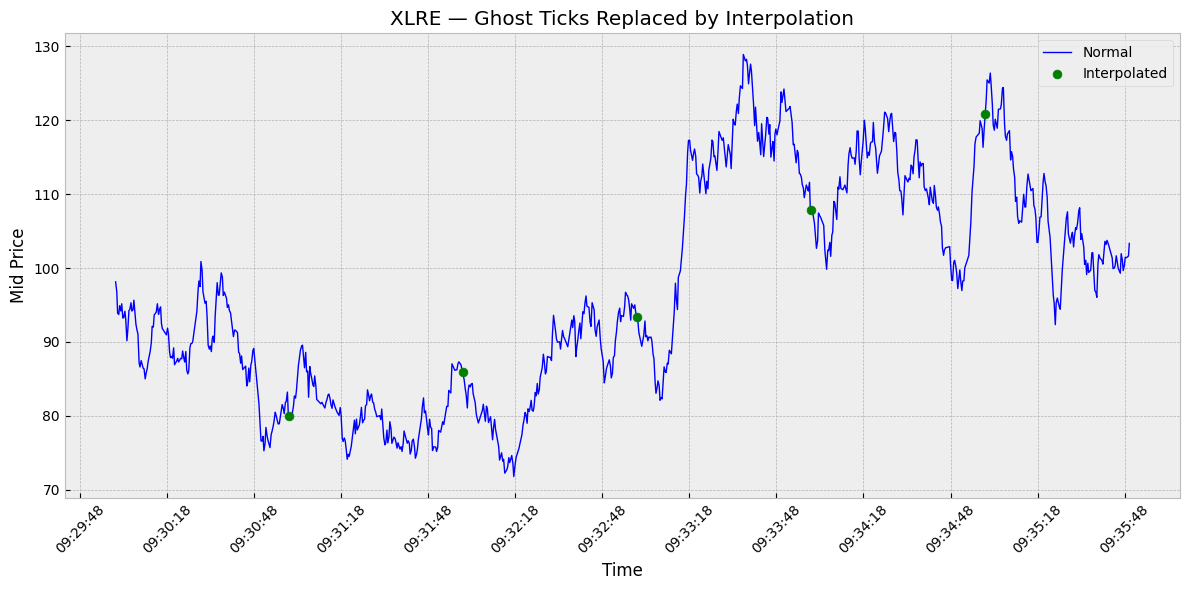

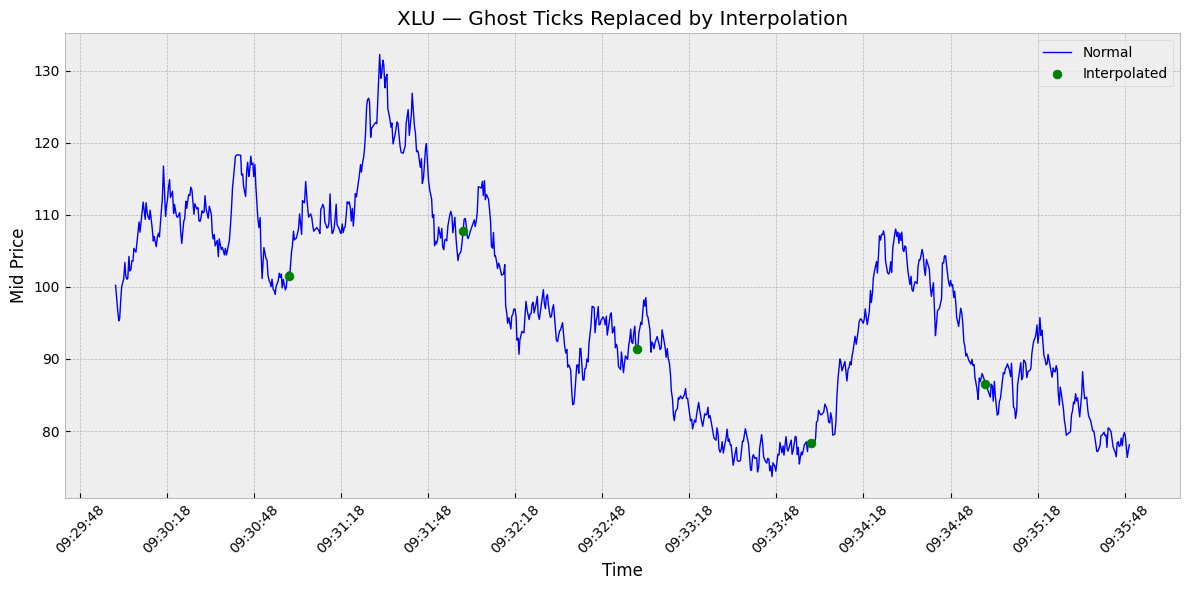

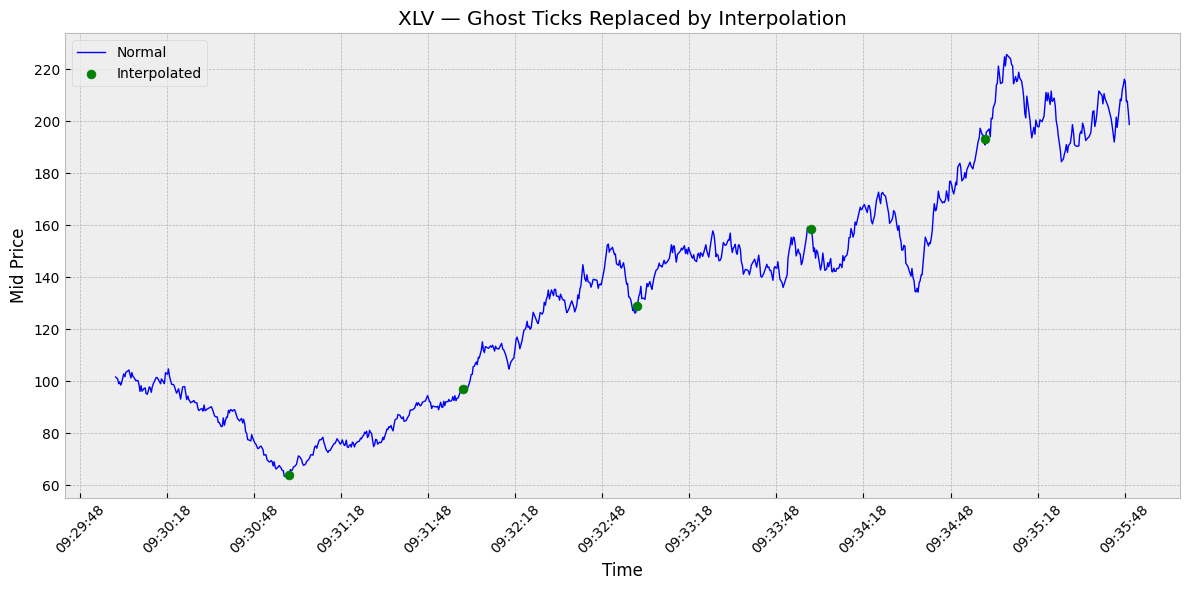

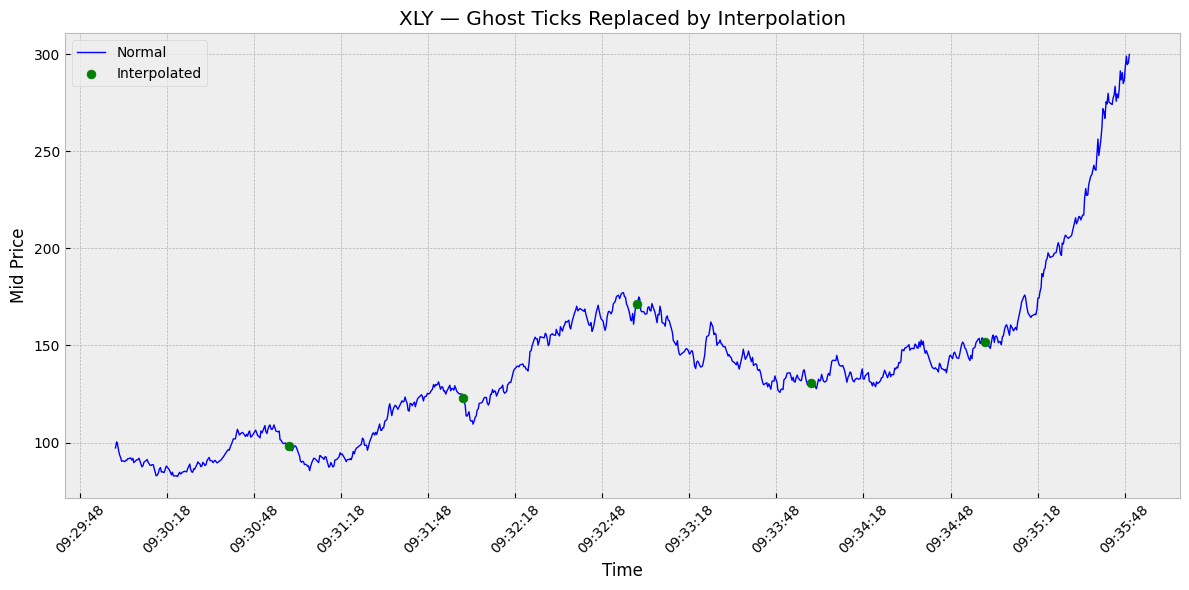

In [14]:
for stock in reduced['ticker'].unique():
    stock_data = reduced[reduced['ticker'] == stock]

    plt.figure(figsize=(12, 6))

    normal = stock_data[~stock_data['is_ghost']]
    ghosts = stock_data[stock_data['is_ghost']]

    plt.plot(normal['timestamps'], normal['mid'], color='blue', linewidth=1, label='Normal')
    plt.scatter(ghosts['timestamps'], ghosts['mid'], color='green', s=40, zorder=5, label='Interpolated')

    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    ax.xaxis.set_major_locator(mdates.SecondLocator(interval=30))
    plt.xticks(rotation=45)
    plt.title(f'{stock} — Ghost Ticks Replaced by Interpolation')
    plt.xlabel('Time')
    plt.ylabel('Mid Price')
    plt.legend()
    plt.tight_layout()
    plt.show()